# Computational Analysis of Retinal Gene Expression

## Objective

This notebook explores simplified transcriptomic analysis methods relevant to retinal biological systems.

## Methods

The notebook uses:
- Pandas for gene-expression-style data organization
- NumPy for numerical computation
- Matplotlib for exploratory visualization

## Biological Context

Retinal cell types differ in molecular identity and gene expression patterns. Computational analysis of expression-style data can help connect cellular identity with biological function.

## Expected Outcome

The notebook is expected to demonstrate introductory computational approaches for analyzing retinal gene-expression-style data.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

np.random.seed(42)

genes = ["RHO", "OPN1SW", "GNAT1", "PDE6B", "CRX", "VSX2", "RBPMS", "THY1"]
cell_types = ["Photoreceptor", "Bipolar", "Ganglion"]

data = []

for cell_type in cell_types:
    for i in range(80):
        if cell_type == "Photoreceptor":
            expression = np.random.normal([8, 7, 8, 7, 6, 2, 1, 1], 1)
        elif cell_type == "Bipolar":
            expression = np.random.normal([2, 2, 2, 2, 4, 8, 2, 2], 1)
        else:
            expression = np.random.normal([1, 1, 2, 2, 3, 2, 8, 7], 1)

        data.append([cell_type] + list(expression))

df = pd.DataFrame(data, columns=["Cell_Type"] + genes)
df.head()

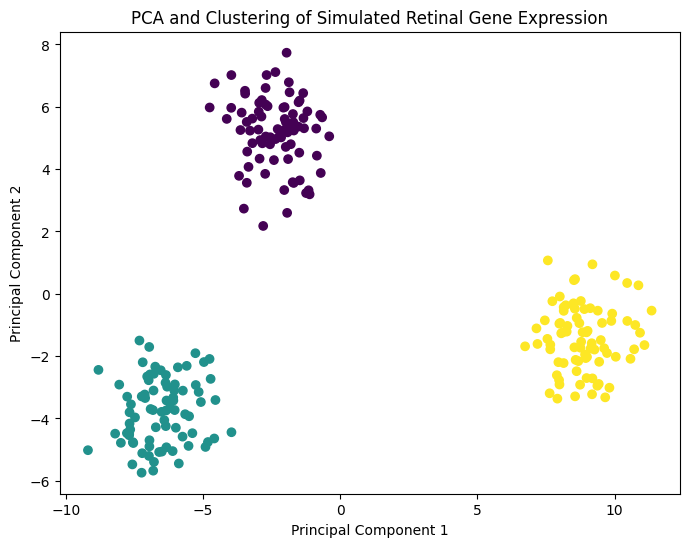

In [ ]:
X = df[genes]

pca = PCA(n_components=2)
components = pca.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)

plt.figure(figsize=(8,6))
plt.scatter(components[:,0], components[:,1], c=clusters)

plt.title("PCA and Clustering of Simulated Retinal Gene Expression")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [ ]:
df.groupby("Cell_Type")[genes].mean()

,RHO,OPN1SW,GNAT1,PDE6B,CRX,VSX2,RBPMS,THY1
Cell_Type,,,,,,,,
Bipolar,2.029405,2.011874,1.956324,2.238936,4.114866,8.116604,2.264265,1.943197
Ganglion,1.074425,1.083115,1.995931,2.150244,2.927231,2.136923,8.043943,6.962527
Photoreceptor,7.956161,7.184844,8.136412,6.982287,6.042388,1.797796,0.848092,1.011115
